
# Persona → Target (LLM) — Minimal Pipeline

This notebook shows a compact, readable pipeline to:
1) Build a short **persona brief** for a respondent from top non-target features,  
2) Ask a **Target** question to a LLM with **allowed labels**,  
3) Evaluate on a small sample (accuracy/F1/precision/recall + confusion matrix),  
4) Export a **submission CSV** with columns: `respondent_id, question_id, prediction`.

> Files used (already provided to you):  
> - `wvs_answer_categories_VERBATIM.json` — question texts + allowed labels  
> - `rank_all_questions.csv` — feature importances per Target  
> - Your train CSV (set its path below).

> The code is intentionally short. Each cell does **one thing** clearly.


In [1]:
import torch

# Print the PyTorch version
print(f"PyTorch version: {torch.__version__}")

# Check for Apple Silicon GPU (MPS) support
if torch.backends.mps.is_available():
    print("✅ MPS (Apple Silicon GPU) is available and will be used for acceleration!")
else:
    print("MPS not found. PyTorch will use the CPU.")

PyTorch version: 2.8.0
✅ MPS (Apple Silicon GPU) is available and will be used for acceleration!



## 0. Setup

- Make sure you have your OpenAI API key available as an environment variable: `OPENAI_API_KEY`.
- Set the path to your **train** CSV (contains `respondent_id`, many `Q*` columns, and `t_Q*` target columns).


In [ ]:
# !pip3 install pandas numpy matplotlib scikit-learn transformers pytorch openai


SyntaxError: invalid syntax (1412537268.py, line 3)

In [ ]:
# --- Installation et Imports ---
#!pip install pandas numpy matplotlib scikit-learn openai tqdm -q

import os
import json
import textwrap
import difflib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import openai
from tqdm.notebook import tqdm

# --- Configuration de l'API OpenAI ---

# ⬇️⬇️⬇️
API_KEY = ""
# ⬆️⬆️⬆️

# On initialise le client OpenAI avec la clé fournie ci-dessus
client = openai.OpenAI(api_key=API_KEY)
print("Client OpenAI configuré avec succès.")


# --- Chemins et Paramètres ---
DATA_DIR = Path("./")
PATH_JSON_Q = DATA_DIR / "wvs_answer_categories_VERBATIM.json"
PATH_RANK   = DATA_DIR / "rank_all_questions.csv"
TRAIN_PATH = DATA_DIR / "train.csv"

TOP_K_FEATURES = 10
MAX_TOKENS_TARGET = 32
MAX_TOKENS_SUMMARY = 512

Client OpenAI configuré avec succès.



## 1. Load JSON & Rank files (and Train if available)


In [ ]:
# --- Chargement des fichiers de métadonnées et de données ---

# Charger le JSON avec le texte des questions et les options de réponse
with open(PATH_JSON_Q, 'r', encoding='utf-8') as f:
    QMAP = json.load(f)

# --- Fonctions utilitaires (VERSION SÉCURISÉE) ---

def q_text(qid: str) -> str:
    """
    Retourne le texte de la question. Si la question est inconnue,
    retourne l'identifiant de la question lui-même pour ne pas planter.
    """
    if qid in QMAP:
        return QMAP[qid].get("question_text", qid)
    return qid # Fallback : retourne l'ID si la question n'est pas dans le JSON

def q_levels_raw(qid: str) -> list[str]:
    """Retourne les options de réponse brutes du JSON."""
    if qid in QMAP and "levels" in QMAP[qid]:
        return list(QMAP[qid]["levels"])
    return [] # Fallback : retourne une liste vide si inconnu

def q_levels(qid: str) -> list[str]:
    """
    Retourne les options de réponse autorisées pour une question.
    """
    return q_levels_raw(qid)

def is_target(qid: str) -> bool:
    """Vérifie si une question est une question 'target'."""
    return qid.startswith("t_")

# Charger le classement des features par importance
rank = pd.read_csv(PATH_RANK)

# Charger le fichier d'entraînement (si présent)
if Path(TRAIN_PATH).exists():
    df = pd.read_csv(TRAIN_PATH)
    print("Fichier d'entraînement chargé :", df.shape)
else:
    df = None
    print("Fichier d'entraînement non trouvé. Certaines cellules pourraient ne pas fonctionner.")

Train loaded: (5000, 266)



## 2. Pick top non-target features for a given Target
We keep `TOP_K_FEATURES` most important **non-target** questions.


In [63]:
def top_features_for_target(t_qid: str, k: int = TOP_K_FEATURES) -> list[str]:
    """
    Version simplifiée : sélectionne les k features les plus importantes pour une
    question target en se basant directement sur la colonne 'score'.
    """
    # Chaîne d'opérations directes et concises
    sub = rank[rank['target'] == t_qid]
    feats = sub.sort_values('score', ascending=False)[lambda x: ~x['feature'].map(is_target)]['feature'].head(k).tolist()
    
    # Fallback simple si la liste est trop courte
    if len(feats) < k:
        fallback_feats = ["B_COUNTRY", "N_REGION_ISO", "Q275", "Q279", "Q260"] # Age, Sexe, Education
        for qid in fallback_feats:
            if len(feats) < k and qid not in feats:
                feats.append(qid)
                
    return feats

# Petit test pour vérifier que la fonction retourne bien une liste de features pertinentes
print("Test de la fonction top_features_for_target (version simplifiée) pour t_Q19 :")
print(top_features_for_target('t_Q19', k=5))

Test de la fonction top_features_for_target (version simplifiée) pour t_Q19 :
['N_REGION_ISO', 'Q21', 'Q23', 'Q223', 'Q26']



## 3. Prompt templates (system + user)

Two stages:
1) **Persona synthesis** from selected answers,  
2) **Target answering** with **allowed labels**.

We will **print the full prompts** for inspection.


In [57]:
# --- SYSTEM (Persona) ---
SYSTEM_PERSONA = (
    "You are an expert behavioral analyst. Your task is to write a concise, narrative description of a survey "
    "respondent based ONLY on the provided answers.\n\n"
    "CRITICAL RULES:\n"
    "1.  **Stick to the Facts**: Base your description ONLY on the provided Question/Answer pairs. Do not invent information.\n"
    "2.  **Handle Missing Data**: If answers are vague or non-committal (e.g., 'No answer', 'Don't know'), state this limitation directly in your analysis. Do NOT make strong inferences from missing data.\n"
    "3.  **Format**: Write a single, fluid paragraph of 100-150 words. The output must be plain text, with no Markdown, headers, lists, or bolding.\n"
    "4.  **No Filler**: Do NOT add any conversational remarks, disclaimers, or hashtags. Your entire output must be the analysis paragraph itself."
)

# --- SYSTEM (Target) ---
SYSTEM_TARGET = (
    "You are an expert in social sciences. Your task is to predict a respondent's answer to a "
    "survey question based on their detailed profile and relevant examples.\n"
    "STRICT OUTPUT RULES:\n"
    "- Choose EXACTLY ONE option from the provided list.\n"
    "- Output ONLY the selected option, VERBATIM, with no explanation or punctuation."
)


# --- Fonctions de construction des prompts ---

def build_persona_user_prompt(respondent_dict: dict[str, str], features: list[str]) -> str:
    lines = []
    for qid in features:
        if qid in respondent_dict and pd.notna(respondent_dict[qid]):
            lines.append(f"Question: {q_text(qid)}\nAnswer: {respondent_dict[qid]}")
    if not lines:
        lines.append("(No usable answers provided)")
    header = "Create a detailed profile for the respondent based on the following survey answers:\n"
    return header + "\n\n" + "\n\n".join(lines)

def get_few_shot_examples_text(df: pd.DataFrame, target_qid: str, target_row: pd.Series, k_examples: int = 1) -> str:
    """
    Crée un ou plusieurs exemples 'few-shot' en trouvant les répondants les plus similaires.
    """
    if df is None or k_examples == 0:
        return ""

    sim_features = top_features_for_target(target_qid, k=20)
    valid_features = [f for f in sim_features if f in df.columns]
    df_subset = df.dropna(subset=[target_qid] + valid_features).copy()
    
    if len(df_subset) < k_examples + 1: return ""

    df_encoded = pd.get_dummies(df_subset[valid_features], columns=valid_features, dummy_na=True)
    
    # --- CORRECTION ICI ---
    # On s'assure que les valeurs sont des entiers (0/1) et non des booléens (True/False)
    df_encoded = df_encoded.astype(int)
    
    try:
        if target_row.name not in df_encoded.index: return ""
        target_vector = df_encoded.loc[target_row.name]
        other_vectors = df_encoded.drop(target_row.name)
    except (IndexError, KeyError):
        return ""

    distances = np.linalg.norm(other_vectors.values - target_vector.values, axis=1)
    similar_indices = other_vectors.index[np.argsort(distances)[:k_examples]]
    sample_examples = df.loc[similar_indices]

    examples = []
    for _, row in sample_examples.iterrows():
        example_feats = top_features_for_target(target_qid, k=5)
        resp_dict = {col: row[col] for col in example_feats if col in row.index and pd.notna(row[col])}
        
        q_and_a = [f"Question: {q_text(qid)}\nAnswer: {ans}" for qid, ans in resp_dict.items()]
        example_persona_text = "\n\n".join(q_and_a)
        example_answer = row[target_qid]
        
        example_text = f"Exemple de cas similaire:\n---\nProfil basé sur les réponses:\n{example_persona_text}\n\nQuestion Cible:\n{q_text(target_qid)}\n\nRéponse Connue: {example_answer}\n---"
        examples.append(example_text)
    
    return "\n\n".join(examples)


def build_target_user_prompt(t_qid: str, persona_brief: str, few_shot_examples: str = "") -> str:
    """
    Construit le prompt de prédiction final, avec les exemples few-shot.
    """
    allowed_options = q_levels(t_qid)
    options_str = "\n".join([f"- {opt}" for opt in allowed_options])
    
    prompt_start = f"{few_shot_examples}\n\nMaintenant, pour le cas à prédire :\n" if few_shot_examples else ""

    return textwrap.dedent(f"""{prompt_start}
    Persona Profile:
    {persona_brief}

    Target Question:
    {q_text(t_qid)}

    Options:
    {options_str}

    Your Prediction:""")


## 4. Simple HF helper
Low temperature to keep outputs deterministic.


In [58]:
## 4. Helper pour l'API OpenAI (version finale et robuste)
def chat_once(system_prompt: str,
              user_prompt: str,
              model: str = "gpt-4o-mini",
              max_tokens: int = 512,
              temperature: float = 0.0) -> str:
    """
    Wrapper pour l'API OpenAI, capable de gérer différents noms de paramètres.
    """
    try:
        # Essai avec le paramètre standard 'max_tokens'
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            max_tokens=max_tokens,
            temperature=temperature
        )
        return response.choices[0].message.content.strip()
    except openai.BadRequestError as e:
        if "Use 'max_completion_tokens' instead" in str(e):
            print("Info : L'API demande 'max_completion_tokens'. Nouvel essai avec ce paramètre.")
            try:
                # Deuxième essai avec le paramètre non standard
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    max_completion_tokens=max_tokens, 
                    temperature=temperature
                )
                return response.choices[0].message.content.strip()
            except Exception as retry_e:
                print(f"La tentative de correction a aussi échoué : {retry_e}")
                return ""
        else:
            print(f"Une erreur inattendue est survenue avec l'API OpenAI : {e}")
            return ""
    except Exception as e:
        print(f"Une erreur générale est survenue : {e}")
        return ""

def build_persona(respondent_row: pd.Series, features: list[str]) -> str:
    """
    Construit le persona en appelant l'API.
    """
    resp_dict = {col: respondent_row[col] for col in features if col in respondent_row.index}
    uprompt = build_persona_user_prompt(resp_dict, features)
    return chat_once(
        system_prompt=SYSTEM_PERSONA,
        user_prompt=uprompt,
        max_tokens=MAX_TOKENS_SUMMARY,
        temperature=0.0
    )

def answer_target(t_qid: str, persona_brief: str, few_shot_examples: str = "") -> str:
    """
    Prédit la réponse à une question target en appelant l'API.
    """
    uprompt = build_target_user_prompt(t_qid, persona_brief, few_shot_examples)
    ans = chat_once(
        system_prompt=SYSTEM_TARGET,
        user_prompt=uprompt,
        max_tokens=MAX_TOKENS_TARGET,
        temperature=0.0
    )
    # Logique de fallback pour s'assurer que la réponse est valide
    allowed = set(q_levels(t_qid))
    cand = ans.strip().strip('"').strip("'")
    if cand in allowed:
        return cand
    matches = difflib.get_close_matches(cand, list(allowed), n=1, cutoff=0.0)
    return matches[0] if matches else list(allowed)[0]


## 5. Build & print the **full prompts** (one respondent × one Target)

This helps validate that the content and allowed labels look correct.


In [59]:
## 5. Build & print the full prompts (one respondent × one Target)

if df is not None:
    # pick first available target and one respondent
    targets = [c for c in df.columns if c.startswith("t_")]
    assert len(targets) > 0, "No t_Q* targets found in train."
    sample_target = targets[0]

    rid = df["respondent_id"].dropna().iloc[0]
    row = df[df["respondent_id"] == rid].iloc[0]

    # select top non-target features for this target
    feats = top_features_for_target(sample_target, k=TOP_K_FEATURES)

    # --- Build persona USER prompt (new simple version) ---
    resp_dict = {col: row[col] for col in feats if col in row.index}
    persona_user_prompt = build_persona_user_prompt(resp_dict, feats)

    print("\n--- SYSTEM (Persona) ---\n", SYSTEM_PERSONA)
    print("\n--- USER (Persona) ---\n", persona_user_prompt)

    # Build the persona using the new prompts
    persona = build_persona(row, feats)
    print("\n--- GENERATED PERSONA (Example) ---\n", persona)


    # Build Target USER prompt (using the new persona)
    target_user_prompt = build_target_user_prompt(sample_target, persona)

    print("\n\n--- SYSTEM (Target) ---\n", SYSTEM_TARGET)
    print("\n--- USER (Target) ---\n", target_user_prompt)

else:
    print("Train not loaded: prompts cannot be built for a concrete respondent.")


--- SYSTEM (Persona) ---
 You are an expert behavioral analyst. Your task is to write a concise, narrative description of a survey respondent based ONLY on the provided answers.

CRITICAL RULES:
1.  **Stick to the Facts**: Base your description ONLY on the provided Question/Answer pairs. Do not invent information.
2.  **Handle Missing Data**: If answers are vague or non-committal (e.g., 'No answer', 'Don't know'), state this limitation directly in your analysis. Do NOT make strong inferences from missing data.
3.  **Format**: Write a single, fluid paragraph of 100-150 words. The output must be plain text, with no Markdown, headers, lists, or bolding.
4.  **No Filler**: Do NOT add any conversational remarks, disclaimers, or hashtags. Your entire output must be the analysis paragraph itself.

--- USER (Persona) ---
 Create a detailed profile for the respondent based on the following survey answers:


Question: Which region do you currently live in?
Answer: Overijssel

Question: Would yo


## 6. Predict on a small sample

- Choose a handful of Target questions (e.g., first 5).  
- For a sample of respondents, build one persona and answer each Target.


In [60]:
## 6. Prédire sur un échantillon avec la logique avancée (version corrigée)
if df is not None:
    TARGETS = [c for c in df.columns if c.startswith("t_")]
    TARGETS_SAMPLE = TARGETS[:5]
    RESP_SAMPLE = df['respondent_id'].dropna().sample(min(30, len(df)), random_state=42)

    preds = []
    print(f"Lancement des prédictions pour {len(RESP_SAMPLE)} répondants et {len(TARGETS_SAMPLE)} questions target...")
    
    # MODIFICATION ICI : On importe la version standard de tqdm qui fonctionne toujours
    from tqdm import tqdm
    
    for rid in tqdm(RESP_SAMPLE, desc="Répondants traités"):
        row = df[df['respondent_id']==rid].iloc[0]
        
        # La logique est maintenant à l'intérieur de la boucle des questions
        for t in TARGETS_SAMPLE:
            # 1. On crée le persona DYNAMIQUE pour chaque question
            feats = top_features_for_target(t, k=TOP_K_FEATURES)
            persona = build_persona(row, feats)
            
            # 2. On trouve des exemples FEW-SHOT pertinents
            few_shot_text = get_few_shot_examples_text(df, t, row, k_examples=1)
            
            # 3. On prédit en utilisant le persona dynamique ET les exemples
            pred = answer_target(t, persona, few_shot_text)
            
            true = row[t] if t in row.index else np.nan
            preds.append({"respondent_id": int(rid), "question_id": t, "y_true": true, "prediction": pred})

    pred_df = pd.DataFrame(preds)
    print("\nPrédictions terminées.")
    display(pred_df.head())
else:
    pred_df = None
    print("Train not loaded: skipping predictions.")

Lancement des prédictions pour 30 répondants et 5 questions target...

































Répondants traités: 100%|██████████| 30/30 [09:34<00:00, 19.16s/it]


Prédictions terminées.


,respondent_id,question_id,y_true,prediction
0,124073208,t_Q19,No,No
1,124073208,t_Q27,Disagree,Disagree
2,124073208,t_Q29,Disagree,Strongly disagree
3,124073208,t_Q40,Neither agree or disagree,Disagree
4,124073208,t_Q51,Never,Never


## 6 REPLACE WITH TEST CSV FILE SENT BY ORGANIZERS


In [ ]:
## 6. Lancer les prédictions finales à partir du fichier de tâches
import ast # On importe ast pour lire les listes de questions dans le CSV

# --- À DÉFINIR DEMAIN ---
# Mettez ici le nom du fichier CSV que vous recevrez
path_to_prediction_file = DATA_DIR / "fichier_a_predire.csv" 
# -------------------------

if df is not None and path_to_prediction_file.exists():
    # 1. Charger le nouveau fichier qui contient les tâches de prédiction
    tasks_df = pd.read_csv(path_to_prediction_file)
    print(f"Fichier de tâches chargé : {len(tasks_df)} lignes à traiter.")
    
    preds = []
    
    # 2. On boucle sur chaque ligne du fichier de tâches
    for _, task_row in tqdm(tasks_df.iterrows(), total=len(tasks_df), desc="Tâches traitées"):
        
        rid = task_row['respondent_id']
        
        # 3. On récupère la liste des questions à prédire pour ce répondant
        # ast.literal_eval convertit la chaîne de caractères "['t_Q19', 't_Q27']" en une vraie liste Python
        try:
            questions_to_predict = ast.literal_eval(task_row['question_list'])
        except (ValueError, SyntaxError):
            print(f"Attention : La liste de questions pour {rid} est mal formatée. Ligne ignorée.")
            continue

        # On récupère les données du répondant dans notre DataFrame principal
        try:
            row = df[df['respondent_id'] == rid].iloc[0]
        except IndexError:
            print(f"Attention : Le répondant {rid} n'a pas été trouvé dans le fichier de données. Ligne ignorée.")
            continue
            
        # 4. On lance la prédiction pour chaque question demandée (votre moteur existant)
        for t in questions_to_predict:
            if not t.startswith("t_"): continue # Sécurité
            
            # Persona dynamique
            feats = top_features_for_target(t, k=TOP_K_FEATURES)
            persona = build_persona(row, feats)
            
            # Exemples Few-Shot
            few_shot_text = get_few_shot_examples_text(df, t, row, k_examples=1)
            
            # Prédiction
            pred = answer_target(t, persona, few_shot_text)
            
            # On stocke le résultat (sans la vraie valeur, car on ne la connaît pas)
            preds.append({"respondent_id": int(rid), "question_id": t, "prediction": pred})

    pred_df = pd.DataFrame(preds)
    print("\nPrédictions finales terminées.")
    display(pred_df.head())

else:
    pred_df = None
    print("Fichier de données d'entraînement (train.csv) ou fichier de tâches non trouvé.")

In [61]:
pred_df

,respondent_id,question_id,y_true,prediction
0,124073208,t_Q19,No,No
1,124073208,t_Q27,Disagree,Disagree
2,124073208,t_Q29,Disagree,Strongly disagree
3,124073208,t_Q40,Neither agree or disagree,Disagree
4,124073208,t_Q51,Never,Never
...,...,...,...,...
145,231070266,t_Q19,No,No
146,231070266,t_Q27,Agree strongly,Agree strongly
147,231070266,t_Q29,Strongly disagree,Strongly disagree
148,231070266,t_Q40,Neither agree or disagree,Strongly agree



## 7. Metrics (accuracy, F1, precision, recall) + Confusion Matrix



=== t_Q19 ===
Accuracy: 0.900 | F1(w): 0.909 | Precision(w): 0.921 | Recall(w): 0.900
              precision    recall  f1-score   support

  Don´t know       1.00      1.00      1.00         1
          No       0.96      0.93      0.94        27
         Yes       0.33      0.50      0.40         2

    accuracy                           0.90        30
   macro avg       0.76      0.81      0.78        30
weighted avg       0.92      0.90      0.91        30



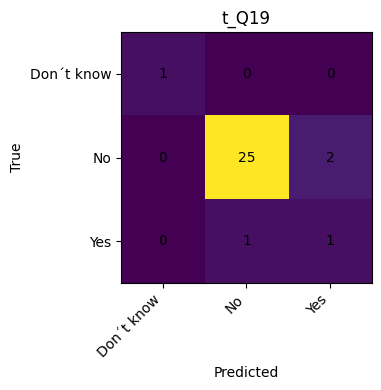


=== t_Q27 ===
Accuracy: 0.600 | F1(w): 0.595 | Precision(w): 0.669 | Recall(w): 0.600
                   precision    recall  f1-score   support

            Agree       0.83      0.45      0.59        11
   Agree strongly       0.77      0.77      0.77        13
         Disagree       0.30      1.00      0.46         3
       Don´t know       0.00      0.00      0.00         1
        No answer       0.00      0.00      0.00         1
Strongly disagree       0.00      0.00      0.00         1

         accuracy                           0.60        30
        macro avg       0.32      0.37      0.30        30
     weighted avg       0.67      0.60      0.60        30



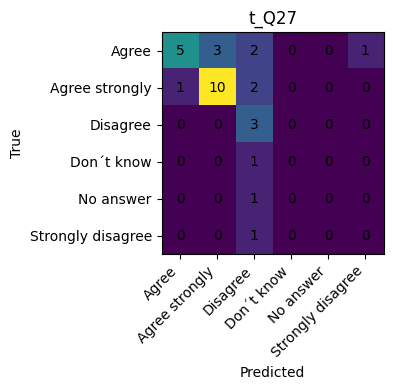


=== t_Q29 ===
Accuracy: 0.533 | F1(w): 0.512 | Precision(w): 0.659 | Recall(w): 0.533
                   precision    recall  f1-score   support

            Agree       1.00      0.56      0.71         9
   Agree strongly       0.80      1.00      0.89         4
         Disagree       0.50      0.17      0.25        12
Strongly disagree       0.31      1.00      0.48         5

         accuracy                           0.53        30
        macro avg       0.65      0.68      0.58        30
     weighted avg       0.66      0.53      0.51        30



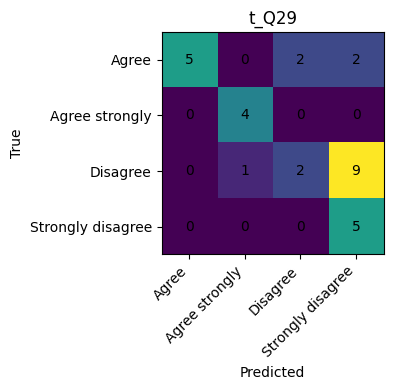


=== t_Q40 ===
Accuracy: 0.467 | F1(w): 0.528 | Precision(w): 0.656 | Recall(w): 0.467
                           precision    recall  f1-score   support

                    Agree       0.60      0.27      0.38        11
                 Disagree       0.00      0.00      0.00         1
Neither agree or disagree       0.57      0.57      0.57         7
           Strongly agree       0.86      0.60      0.71        10
        Strongly disagree       0.50      1.00      0.67         1

                 accuracy                           0.47        30
                macro avg       0.51      0.49      0.46        30
             weighted avg       0.66      0.47      0.53        30



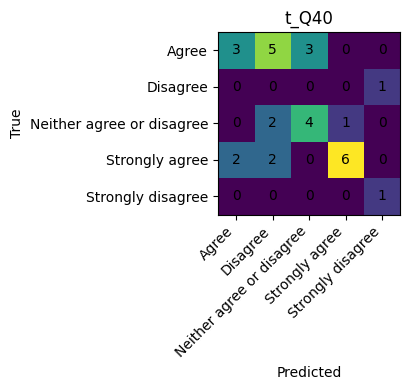


=== t_Q51 ===
Accuracy: 0.933 | F1(w): 0.920 | Precision(w): 0.922 | Recall(w): 0.933
              precision    recall  f1-score   support

       Never       1.00      1.00      1.00        22
       Often       0.00      0.00      0.00         1
      Rarely       1.00      0.67      0.80         3
   Sometimes       0.67      1.00      0.80         4

    accuracy                           0.93        30
   macro avg       0.67      0.67      0.65        30
weighted avg       0.92      0.93      0.92        30



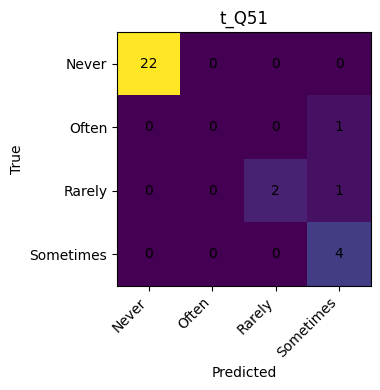

,target,accuracy,f1_w,precision_w,recall_w
4,t_Q51,0.933333,0.920000,0.922222,0.933333
0,t_Q19,0.900000,0.909057,0.920940,0.900000
1,t_Q27,0.600000,0.595173,0.668889,0.600000
3,t_Q40,0.466667,0.528350,0.655714,0.466667
2,t_Q29,0.533333,0.512169,0.658750,0.533333


In [62]:

if pred_df is not None and not pred_df.empty:
    metrics_rows = []
    for t in sorted(pred_df['question_id'].unique()):
        sub = pred_df[pred_df['question_id']==t].dropna(subset=['y_true','prediction'])
        if sub.empty:
            continue
        labels = sorted(set(sub['y_true']) | set(sub['prediction']))
        y_true = sub['y_true'].values
        y_pred = sub['prediction'].values

        acc = accuracy_score(y_true, y_pred)
        f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        pre = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)

        print(f"\n=== {t} ===")
        print(f"Accuracy: {acc:.3f} | F1(w): {f1w:.3f} | Precision(w): {pre:.3f} | Recall(w): {rec:.3f}")
        print(classification_report(y_true, y_pred, zero_division=0))

        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure(figsize=(5,4))
        plt.imshow(cm, interpolation='nearest')
        plt.title(t)
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout()
        plt.show()

        metrics_rows.append({"target":t, "accuracy":acc, "f1_w":f1w, "precision_w":pre, "recall_w":rec})
    metrics_df = pd.DataFrame(metrics_rows).sort_values('f1_w', ascending=False)
    display(metrics_df)
else:
    print("No predictions to evaluate.")


## 8. Export **submission CSV**

Required format:
```
respondent_id,question_id,prediction
320070867,t_Q19,No
320070867,t_Q27,Agree
...
```


In [64]:

if pred_df is not None:
    sub = pred_df[['respondent_id','question_id','prediction']].copy()
    out_path = Path('predictions_submission.csv')
    sub.to_csv(out_path, index=False)
    print('Saved:', out_path)
    display(sub.head())
else:
    print("Nothing to save yet (no predictions).")

Saved: predictions_submission.csv


,respondent_id,question_id,prediction
0,124073208,t_Q19,No
1,124073208,t_Q27,Disagree
2,124073208,t_Q29,Strongly disagree
3,124073208,t_Q40,Disagree
4,124073208,t_Q51,Never
